In [3]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


from envs import BuySellEnv, BaseStoppingEnv
from algorithms import QLearningAgent,QOptimalBehaviourAgent, linear_decay_schedule, LongstaffSchwartzAgentBuySell
from helpers import visualizer, PolicyEvaluator, PolicySnapshotCallback

### LSM Whoops Q-Learning's Ass for Buy-Sell Env

In [ ]:
from algorithms.longstaff_schwartz import LongstaffSchwartzAgent

# Create environment
env_lsm = BuySellEnv(
    n_states=25,
    max_time=30,
    holding_cost_per_step=0.5,
    transition_model="brownian",
    transition_params={"mu": 15, "sigma": 10},
)

# Get optimal policy for comparison
V_opt, policy_opt = env_lsm.solve_optimal_policy()

# Train LSM
print("Training LSM...")
lsm_agent = LongstaffSchwartzAgent(env=env_lsm, poly_degree=3, seed=42)
lsm_time = lsm_agent.train(n_paths=500, seed=42)
print(f"LSM training time: {lsm_time:.2f}s")

# Train Q-Learning for comparison
print("\nTraining Q-Learning...")
n_ep = 500000
sched = linear_decay_schedule(1.0, 0.1, n_ep)
cb = PolicySnapshotCallback(snapshot_interval=3000)
ql_agent = QLearningAgent(env=env_lsm, alpha_schedule=sched, epsilon_schedule=sched)
ql_agent.train(env=env_lsm, n_episodes=n_ep, callbacks=[cb], verbose=0)

# Get policies
policy_lsm = lsm_agent.get_policy()
policy_ql = ql_agent.get_policy()

print("\nEvaluating all policies...")

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 13.7491
  Buy (stop 1) accept rate: 51.20%
  Sell (stop 2) accept rate: 15.73%
Training LSM...
Phase 1: Computing optimal SELL policy (stops_left=1)...


  Sell phase: 100%|██████████| 29/29 [00:00<00:00, 3810.61it/s]


Phase 2: Computing optimal BUY policy (stops_left=2)...


  Buy phase: 100%|██████████| 29/29 [00:00<00:00, 3698.68it/s]

Training complete in 0.27s
  Buy policy accept rate: 47.45%
  Sell policy accept rate: 15.47%
LSM training time: 0.27s

Training Q-Learning...


Training:   0%|                                                      | 0/50000 [00:00<?, ?episode/s]


Evaluating all policies...


Evaluating Q-Learning: 100%|██████████| 2000/2000 [00:00<00:00, 11320.46it/s]



Evaluation Summary: Q-Learning
Episodes: 2000

Reward Statistics:
  Mean:         10.4883
  Std:           5.4610
  Sharpe:        1.9206
  Median:       10.5000
  Min:         -16.5000
  Max:          23.5000

Episode Length:
  Mean:            6.73
  Std:             5.52

Buy-Sell Specific Metrics:
  Completion rate:   97.95%
  Mean buy price:     10.0500
  Mean sell price:    21.9076
  Mean profit:        11.8576
  Mean holding time:     2.30



Evaluating LSM: 100%|██████████| 2000/2000 [00:00<00:00, 6921.71it/s]



Evaluation Summary: LSM
Episodes: 2000

Reward Statistics:
  Mean:         12.9733
  Std:           5.2300
  Sharpe:        2.4805
  Median:       13.5000
  Min:         -11.0000
  Max:          23.5000

Episode Length:
  Mean:           14.39
  Std:             9.45

Buy-Sell Specific Metrics:
  Completion rate:   94.20%
  Mean buy price:      7.4278
  Mean sell price:    22.8121
  Mean profit:        15.3843
  Mean holding time:     3.22



Evaluating Optimal (DP): 100%|██████████| 2000/2000 [00:00<00:00, 6921.44it/s]



Evaluation Summary: Optimal (DP)
Episodes: 2000

Reward Statistics:
  Mean:         12.9720
  Std:           4.8174
  Sharpe:        2.6927
  Median:       13.5000
  Min:         -15.5000
  Max:          23.0000

Episode Length:
  Mean:           13.67
  Std:             9.13

Buy-Sell Specific Metrics:
  Completion rate:   97.55%
  Mean buy price:      7.8883
  Mean sell price:    22.8216
  Mean profit:        14.9334
  Mean holding time:     3.27


Policy Comparison: Q-Learning vs LSM vs Optimal (DP)

Metric                      Q-Learning          LSM Optimal (DP)           Best
--------------------------------------------------------------------------------
Mean Reward                    10.4883      12.9733      12.9720            LSM
Std Reward                      5.4610       5.2300       4.8174   Optimal (DP)
Sharpe Ratio                    1.9206       2.4805       2.6927   Optimal (DP)
Median Reward                  10.5000      13.5000      13.5000            LSM
Mean Epis

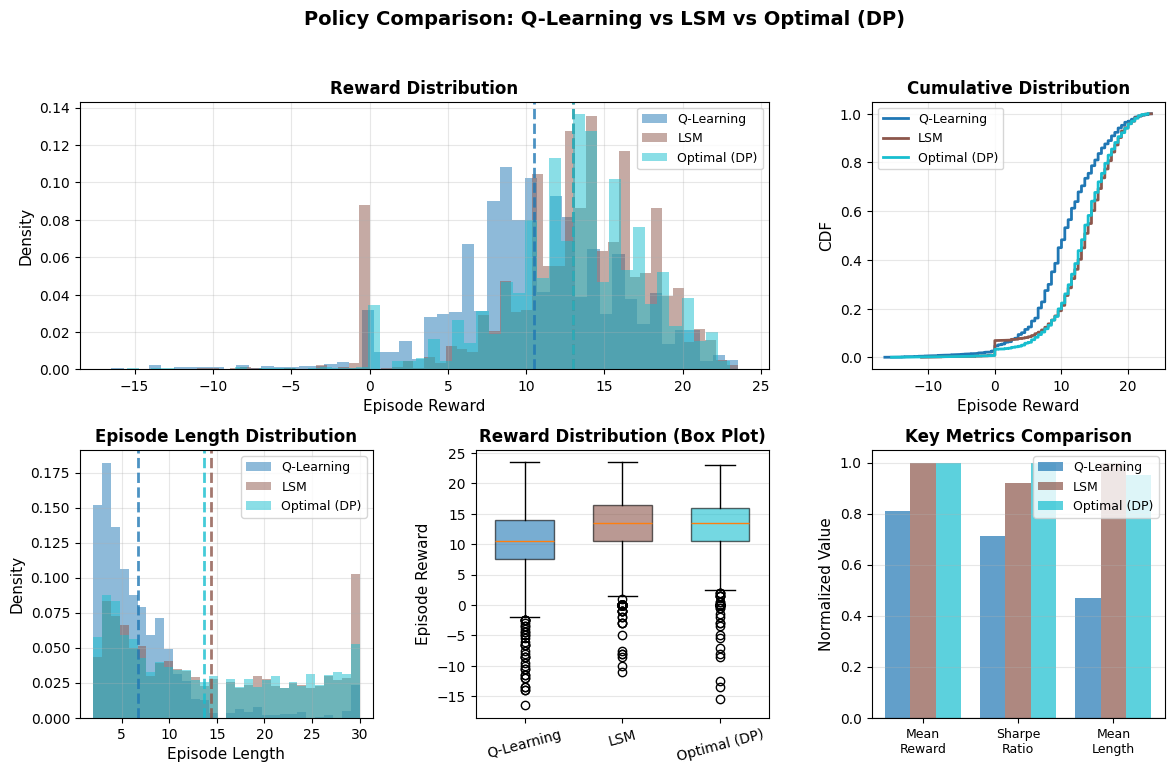

Evaluation complete.


In [ ]:
# Compare all methods
pe = PolicyEvaluator(env_lsm)
pe.compare_policies(
    policies=[policy_ql, policy_lsm, policy_opt],
    policy_names=["Q-Learning", "LSM", "Optimal (DP)"],
    n_episodes=2000
)
pe.plot_comparison()
print("Evaluation complete.")

LSM


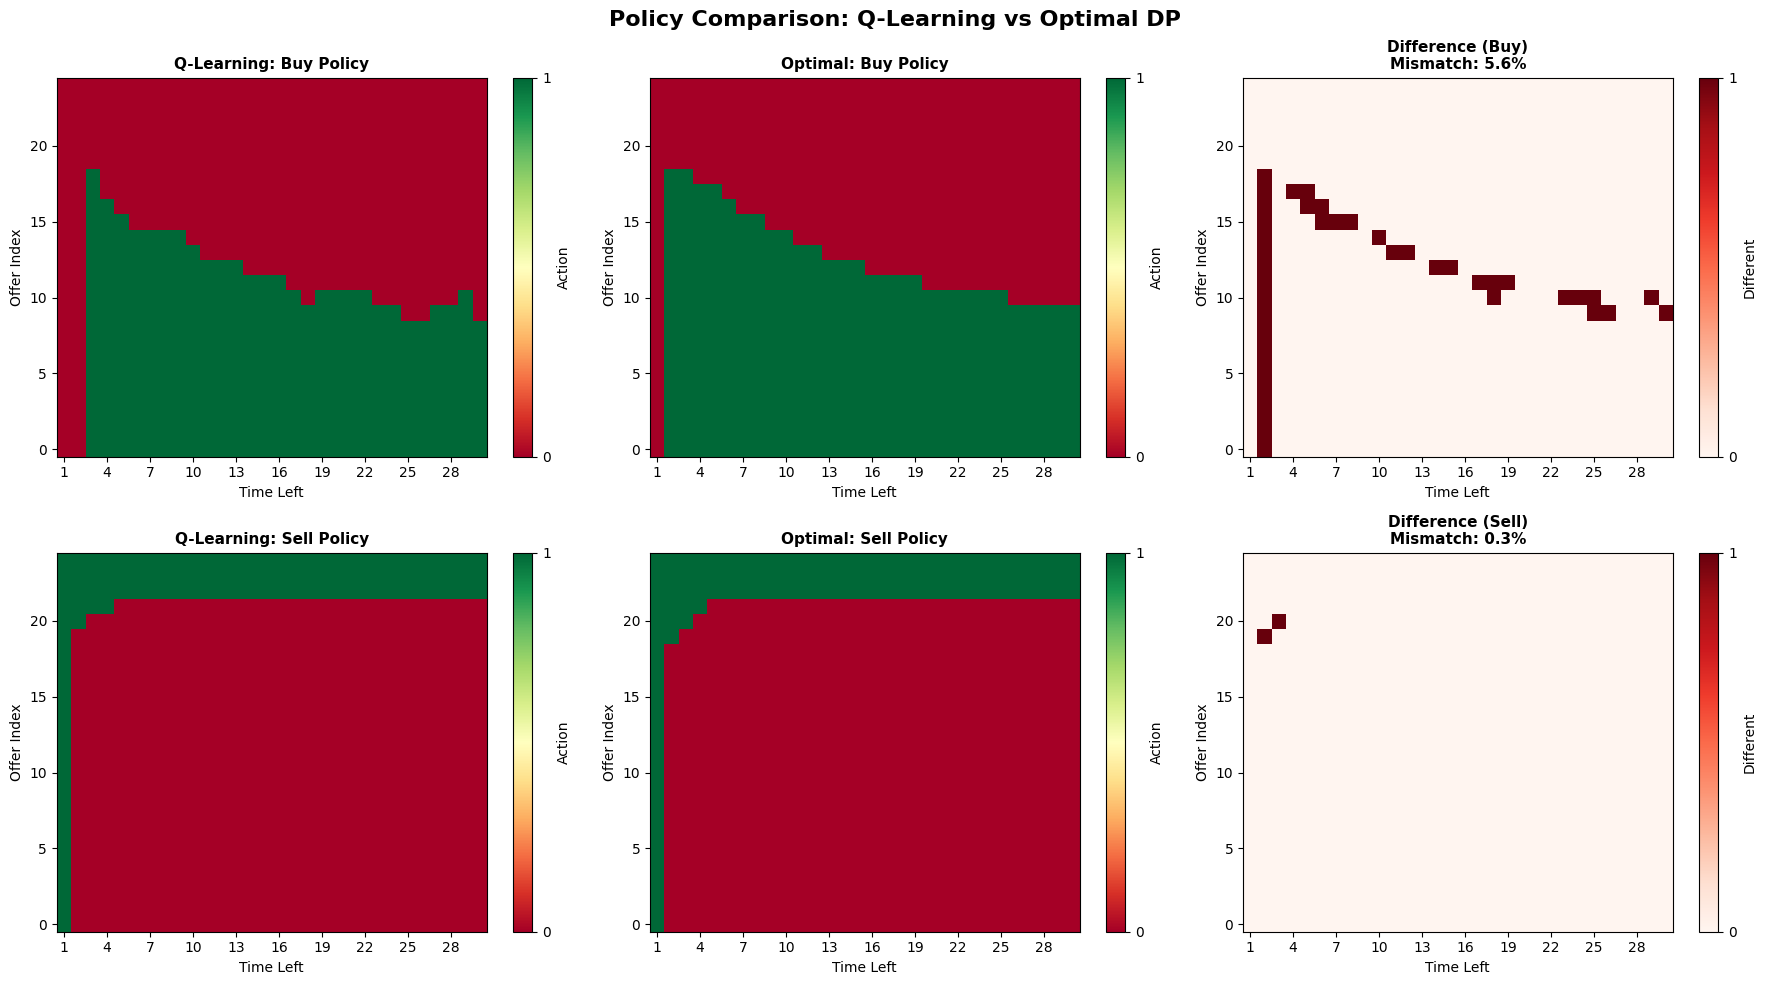


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 45.87%
  Optimal accept rate: 51.20%
  Agreement: 94.40%
  Mismatch: 5.60%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 15.47%
  Optimal accept rate: 15.73%
  Agreement: 99.73%
  Mismatch: 0.27%

Overall Policy Agreement: 97.07%
QL


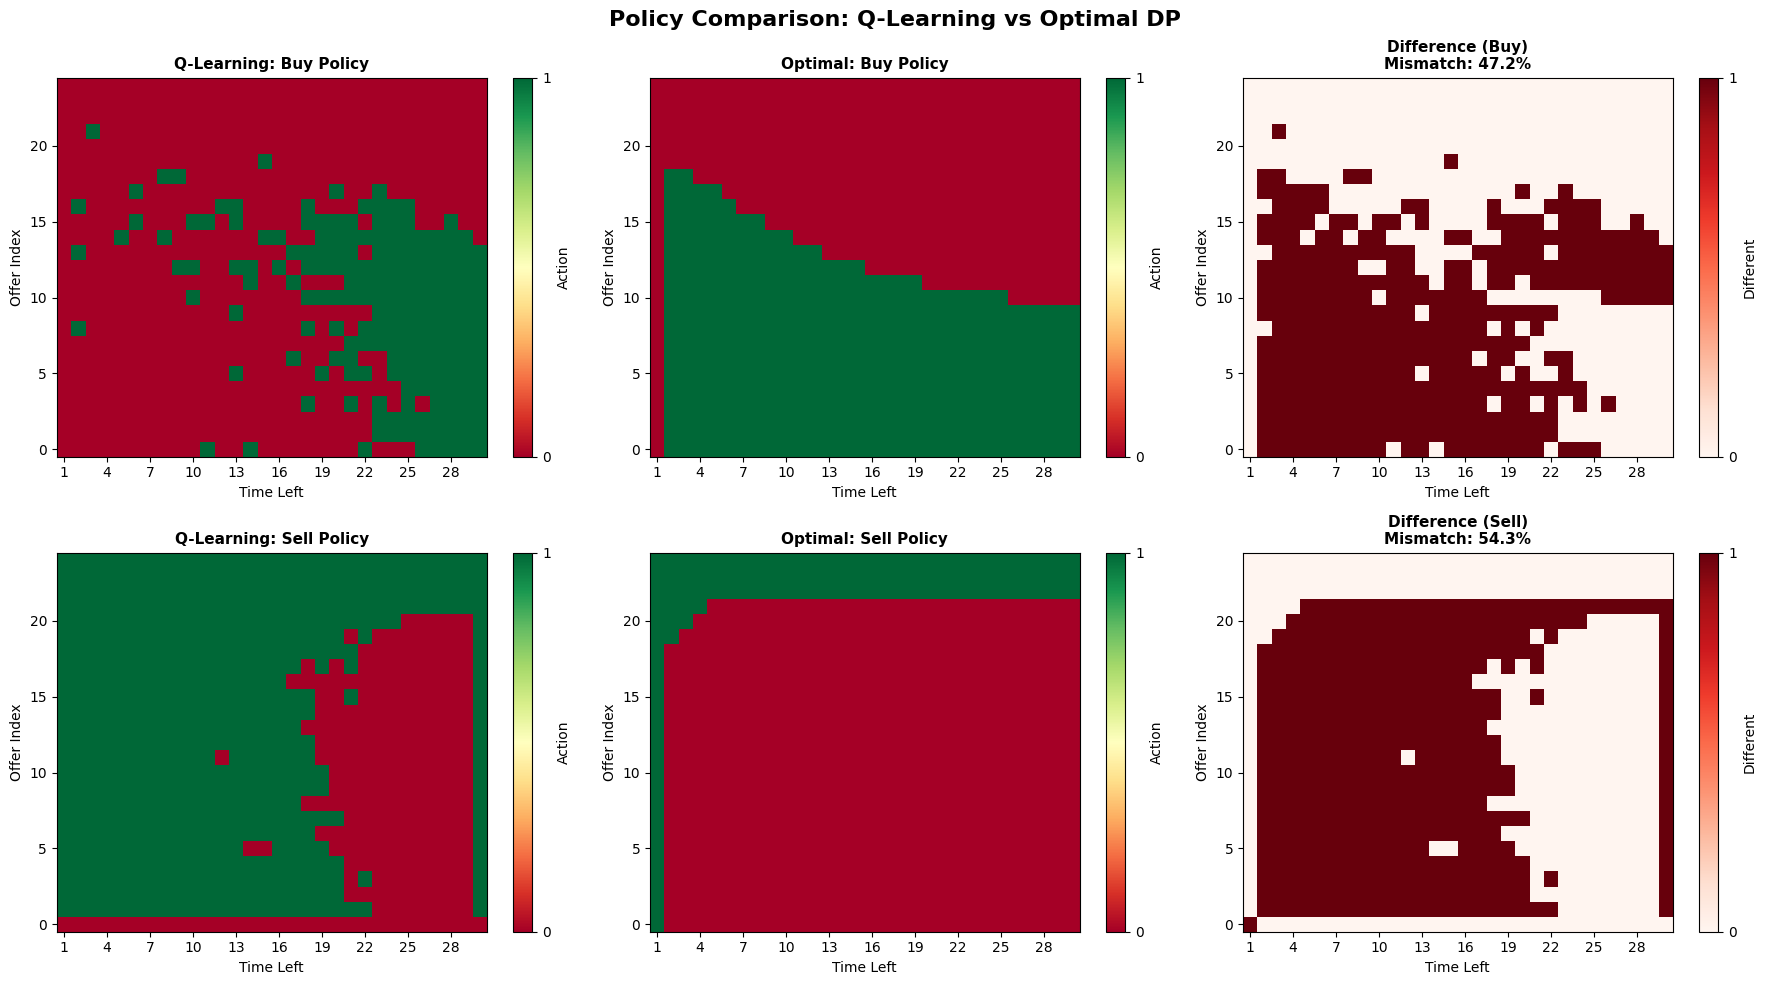


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 25.33%
  Optimal accept rate: 51.20%
  Agreement: 52.80%
  Mismatch: 47.20%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 69.73%
  Optimal accept rate: 15.73%
  Agreement: 45.73%
  Mismatch: 54.27%

Overall Policy Agreement: 49.27%
Creating GIF with 17 frames...
  Rendered frame 10/17
  Rendered frame 17/17
✓ GIF saved to: policy_evolution.gif
  - 17 frames at 5 FPS
  - Duration: 3.4 seconds


'policy_evolution.gif'

In [ ]:
viz = visualizer(env_lsm, lsm_agent, optimal_policy=policy_opt, policy=policy_lsm, policy_provided=True)
print("="*70)
print("LSM which saw only 500 paths")
print("="*70)

viz.compare_with_optimal()

viz = visualizer(env_lsm, ql_agent, optimal_policy=policy_opt, policy_provided=False)
print("="*70)
print("QL which saw 5 lakh paths")
print("="*70)
viz.compare_with_optimal()
viz.create_policy_evolution_gif_with_callback(callback=cb, optimal_policy=policy_opt)   

In [ ]:
print("\nTraining Q-Learning...")
n_ep = 500000
sched = linear_decay_schedule(1.0, 0.1, n_ep)
cb = PolicySnapshotCallback(snapshot_interval=5000)
ql_agent = QLearningAgent(env=env_lsm, alpha_schedule=sched, epsilon_schedule=sched)
ql_agent.train(env=env_lsm, n_episodes=n_ep, callbacks=[cb], verbose=0)

# Get policies
policy_lsm = lsm_agent.get_policy()
policy_ql = ql_agent.get_policy()

viz = visualizer(env_lsm, ql_agent, optimal_policy=policy_opt, policy_provided=False)
viz.create_policy_evolution_gif_with_callback(callback=cb, optimal_policy=policy_opt)


Training Q-Learning...


Training:   0%|                                                     | 0/500000 [00:00<?, ?episode/s]

Creating GIF with 100 frames...
  Rendered frame 10/100
  Rendered frame 20/100
  Rendered frame 30/100
  Rendered frame 40/100
  Rendered frame 50/100
  Rendered frame 60/100
  Rendered frame 70/100
  Rendered frame 80/100
  Rendered frame 90/100
  Rendered frame 100/100
✓ GIF saved to: policy_evolution.gif
  - 100 frames at 5 FPS
  - Duration: 20.0 seconds


'policy_evolution.gif'

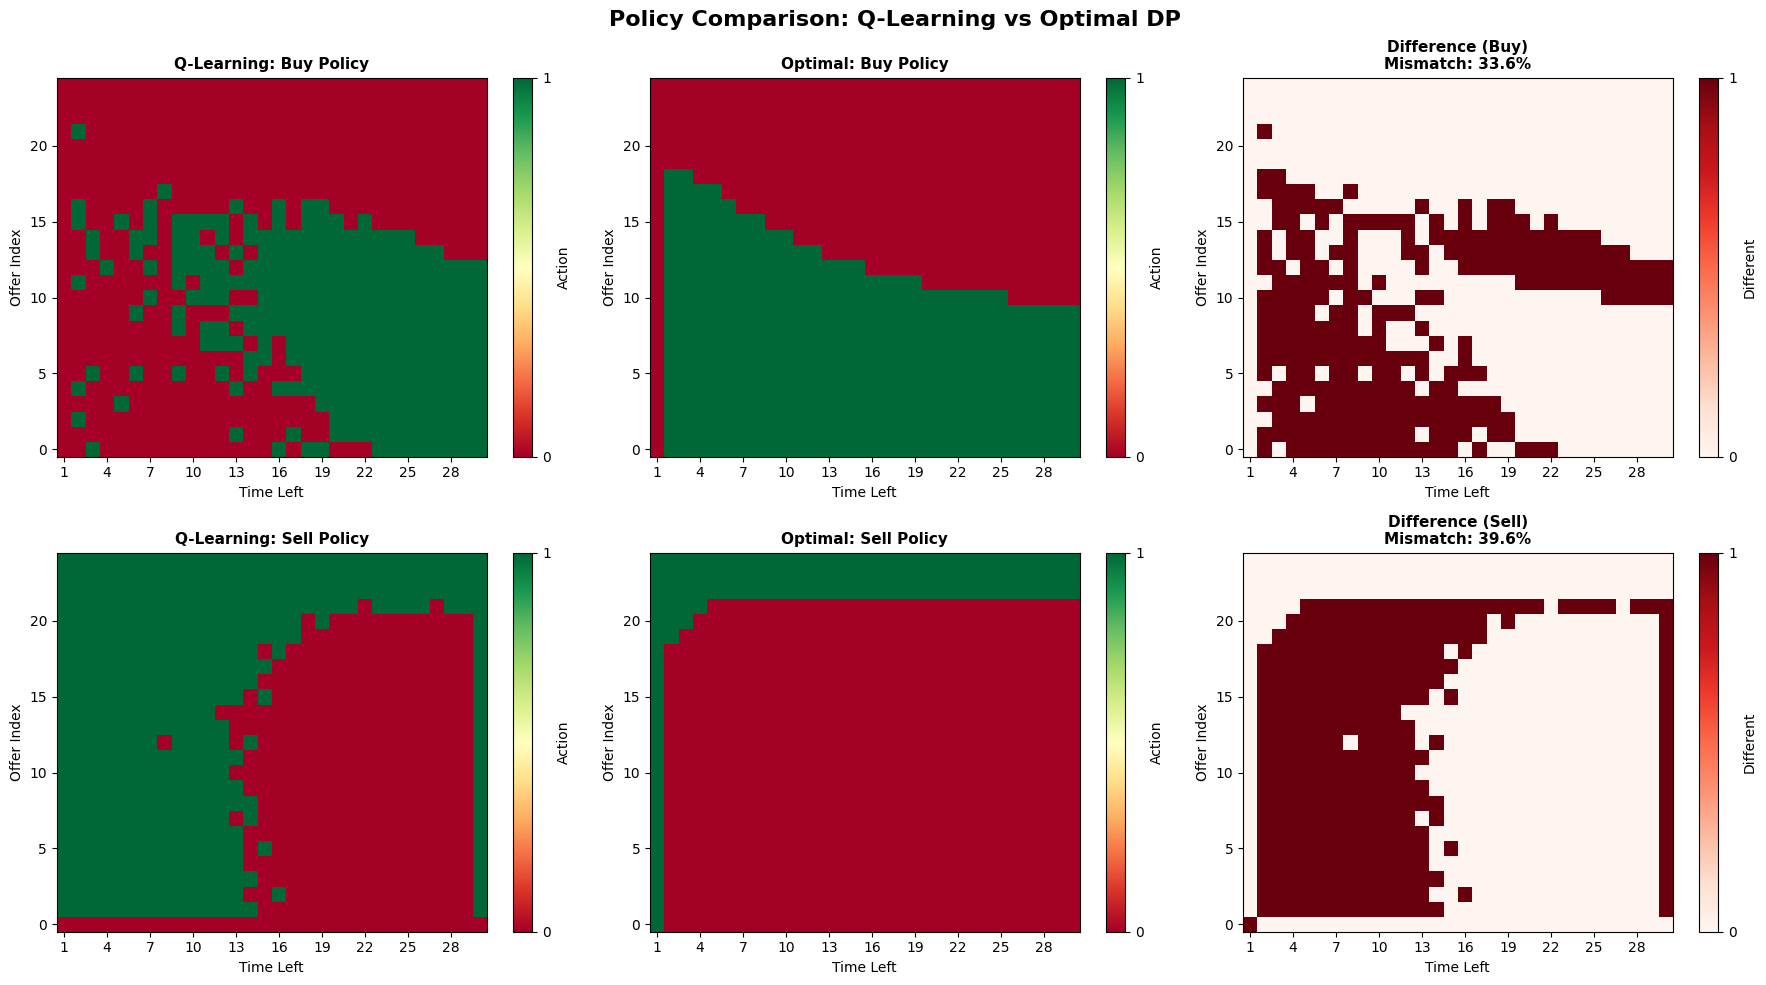


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 37.60%
  Optimal accept rate: 51.20%
  Agreement: 66.40%
  Mismatch: 33.60%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 55.07%
  Optimal accept rate: 15.73%
  Agreement: 60.40%
  Mismatch: 39.60%

Overall Policy Agreement: 63.40%


In [ ]:
viz.compare_with_optimal()